         x1        x2  etiqueta
0 -0.008864  0.113353         1
1  0.242456 -0.075897         1
2 -0.014196 -0.070382         1
3 -0.165579 -0.143002         1
4  0.202125  0.327485         1


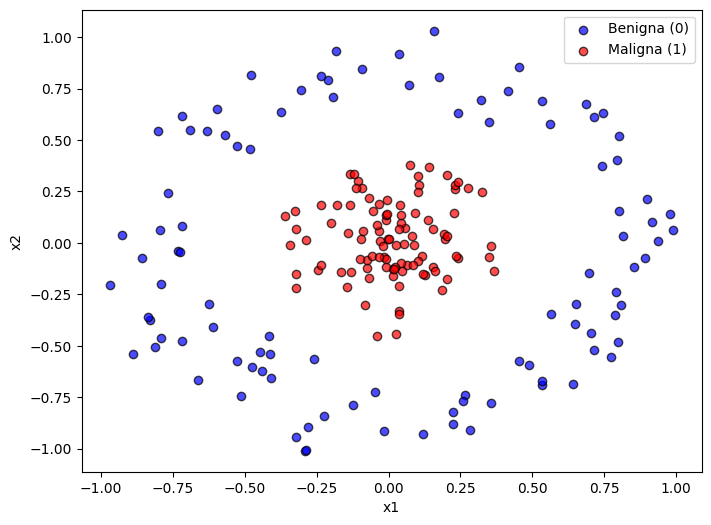

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# 1. Configurar semilla para reproducibilidad
np.random.seed(42)
 
# 2. Definir parámetros
n_samples_per_class = 100  # 100 para benignas (0) y 100 para malignas (1)
n_total = n_samples_per_class * 2
 
# 3. Generar círculos concéntricos
 # Clase 1: Círculo interno (Malignas)
theta_0 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_0 = np.random.uniform(0, 0.4, n_samples_per_class)  # Radio interno pequeño
x1_0 = r_0 * np.cos(theta_0)
x2_0 = r_0 * np.sin(theta_0)
y_0 = np.ones(n_samples_per_class)
 
# Clase 0: Círculo externo (Benignas)
theta_1 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_1 = np.random.uniform(0.7, 1.0, n_samples_per_class)  # Radio externo grande
x1_1 = r_1 * np.cos(theta_1)
x2_1 = r_1 * np.sin(theta_1)
y_1 = np.zeros(n_samples_per_class)
 
# 4. Combinar los datos
x1 = np.concatenate([x1_0, x1_1])
x2 = np.concatenate([x2_0, x2_1])
etiqueta = np.concatenate([y_0, y_1])
 
# 5. Agregar ruido al valor de x2
ruido = np.random.normal(0, 0.08, n_total)  # Ruido gaussiano con media 0 y desviación estándar 0.08
x2 = x2 + ruido
 
# 6. Crear un DataFrame de Pandas
df_celulas = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'etiqueta': etiqueta.astype(int)
})
 
# Mostrar las primeras 5 filas del dataset
print(df_celulas.head())
 
# 7. (Opcional) Visualizar los datos generados
plt.figure(figsize=(8, 6))
plt.scatter(df_celulas[df_celulas['etiqueta'] == 0]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 0]['x2'], 
            color='blue', label='Benigna (0)', alpha=0.7, edgecolors='k')
plt.scatter(df_celulas[df_celulas['etiqueta'] == 1]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 1]['x2'], 
            color='red', label='Maligna (1)', alpha=0.7, edgecolors='k')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

Iteration 1, loss = 0.76327433
Iteration 2, loss = 0.74921562
Iteration 3, loss = 0.73178219
Iteration 4, loss = 0.71392768
Iteration 5, loss = 0.69834385
Iteration 6, loss = 0.68677949
Iteration 7, loss = 0.67968234
Iteration 8, loss = 0.67641199
Iteration 9, loss = 0.67579973
Iteration 10, loss = 0.67665721
Iteration 11, loss = 0.67804295
Iteration 12, loss = 0.67932274
Iteration 13, loss = 0.68012806
Iteration 14, loss = 0.68028719
Iteration 15, loss = 0.67976267
Iteration 16, loss = 0.67860353
Iteration 17, loss = 0.67691135
Iteration 18, loss = 0.67481649
Iteration 19, loss = 0.67246079
Iteration 20, loss = 0.66998404
Iteration 21, loss = 0.66751228
Iteration 22, loss = 0.66514722
Iteration 23, loss = 0.66295733
Iteration 24, loss = 0.66097208
Iteration 25, loss = 0.65918119
Iteration 26, loss = 0.65753979
Iteration 27, loss = 0.65597879
Iteration 28, loss = 0.65441859
Iteration 29, loss = 0.65278287
Iteration 30, loss = 0.65100989
Iteration 31, loss = 0.64905931
Iteration 32, los

C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


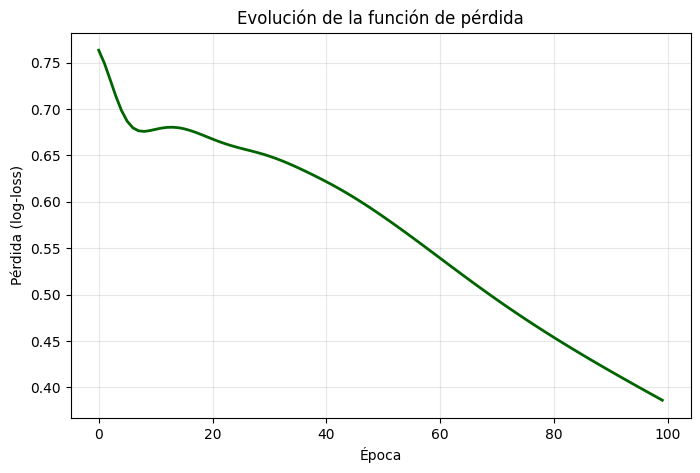

In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Usar todas las observaciones, sin normalización ni división entrenamiento-prueba
X = df_celulas[['x1', 'x2']]
y = df_celulas['etiqueta']

# Red neuronal MLP: 3 capas ocultas, full-batch y parada por la función de pérdida
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    activation='tanh',
    solver='sgd',
    learning_rate_init=0.03,
    learning_rate='adaptive',
    momentum=0.9,
    max_iter=100,
    batch_size=X.shape[0],
    tol=0.001,
    n_iter_no_change=10,
    early_stopping=False,
    random_state=42,
    verbose=True
)

modelo_mlp.fit(X, y)

# Evaluar el modelo sobre todas las observaciones
predicciones = modelo_mlp.predict(X)
print(f'Épocas ejecutadas: {modelo_mlp.n_iter_}')
print(f'Exactitud en todos los datos: {accuracy_score(y, predicciones):.3f}')
print(classification_report(
    y,
    predicciones,
    labels=[0, 1],
    target_names=['Benigna (0)', 'Maligna (1)'],
    zero_division=0
))

# Visualizar la función de pérdida durante el entrenamiento
plt.figure(figsize=(8, 5))
plt.plot(modelo_mlp.loss_curve_, color='darkgreen', linewidth=2)
plt.xlabel('Época')
plt.ylabel('Pérdida (log-loss)')
plt.title('Evolución de la función de pérdida')
plt.grid(alpha=0.3)
plt.show()

In [16]:
#Darle persistencia al modelo entrenado
import joblib

# Guardar el modelo entrenado
joblib.dump(modelo_mlp, 'modelo_mlp_circulos_concentricos.pkl')

['modelo_mlp_circulos_concentricos.pkl']

In [15]:
# Reporte de clasificación para las clases 0 y 1
reporte_clasificacion = classification_report(
    y,
    predicciones,
    labels=[0, 1],
    target_names=['0', '1'],
    digits=3,
    zero_division=0
)

print('Reporte de clasificación')
print(reporte_clasificacion)

Reporte de clasificación
              precision    recall  f1-score   support

           0      0.919     0.790     0.849       100
           1      0.816     0.930     0.869       100

    accuracy                          0.860       200
   macro avg      0.867     0.860     0.859       200
weighted avg      0.867     0.860     0.859       200



In [17]:
# Predicción para x1=0.1 y x2=0.1
punto_nuevo = pd.DataFrame({'x1': [0.1], 'x2': [0.1]})

# El modelo recibe los datos originales, sin normalización
clase_predicha = int(modelo_mlp.predict(punto_nuevo)[0])
probabilidades = modelo_mlp.predict_proba(punto_nuevo)[0]
probabilidad_clase = probabilidades[clase_predicha]

if clase_predicha == 1:
    nombre_clase = 'célula maligna'
else:
    nombre_clase = 'célula benigna'

print(f'Predicción para x1=0.1 y x2=0.1: {clase_predicha}')
print(f'Clase: {nombre_clase}')
print(f'Probabilidad de la clase predicha: {probabilidad_clase:.3%}')
print(f'Probabilidad de clase 0 (benigna): {probabilidades[0]:.3%}')
print(f'Probabilidad de clase 1 (maligna): {probabilidades[1]:.3%}')

Predicción para x1=0.1 y x2=0.1: 1
Clase: célula maligna
Probabilidad de la clase predicha: 81.480%
Probabilidad de clase 0 (benigna): 18.520%
Probabilidad de clase 1 (maligna): 81.480%
